# Segmentation + Evaluation

2025-08-02 16:34:50 — INFO — Evaluation notebook start.
2025-08-02 16:34:50 — INFO — Installing python-dotenv (missing)
2025-08-02 16:34:51 — INFO — Installing Pillow (missing)
2025-08-02 16:34:53 — INFO — Installing google-genai (missing)
2025-08-02 16:34:54 — INFO — GenAI client initialized.
2025-08-02 16:34:54 — INFO — LITS dataset found at D:\Projects\gemini_image_segmentation\data\LITS
2025-08-02 16:34:54 — INFO — Starting evaluation run for model: gemini-2.5-flash on LITS dataset for target: liver.
2025-08-02 16:34:54 — INFO — Loading and processing lits_df.csv
2025-08-02 16:34:58 — INFO — Identifying positive cases based on 'liver_mask_empty' column...
2025-08-02 16:35:04 — INFO — Found 19143 total positive cases for 'liver'.
2025-08-02 16:35:04 — INFO — Detailed predictions will be saved to: D:\Projects\gemini_image_segmentation\data\LITS\predictions_liver_gemini-2.5-flash
2025-08-02 16:35:04 — INFO — Will evaluate a sample of 1000 images using up to 8 threads.
Evaluating liver

---------------------------------------------
         GenAI Segmentation Evaluation Report: gemini-2.5-flash on LITS
         Target: Liver
---------------------------------------------
Total Images Evaluated: 1000
IoU Threshold for Success: 0.5
Exclude Low IoU from Stats: True

--- Performance Metrics ---
Mean IoU (Liver):   0.6359 (95% CI: 0.6253 - 0.6464) on 215 images
Mean Dice (Liver):  0.7745 (95% CI: 0.7666 - 0.7824)

--- Operational Metrics ---
Mean API Latency:        7.12s (95% CI: 4.89s - 9.67s)
JSON Parse Success:      95.4%

--- Failure Analysis (based on full dataset) ---
JSON Failures:           46 (4.6%)
False Negatives:         102 (10.2%)
Low IoU:                 637 (63.7%)
---------------------------------------------


2025-08-02 16:51:30 — INFO — Saved high-resolution IoU plot to D:\Projects\gemini_image_segmentation\data\LITS\iou_distribution_liver_gemini-2.5-flash.png


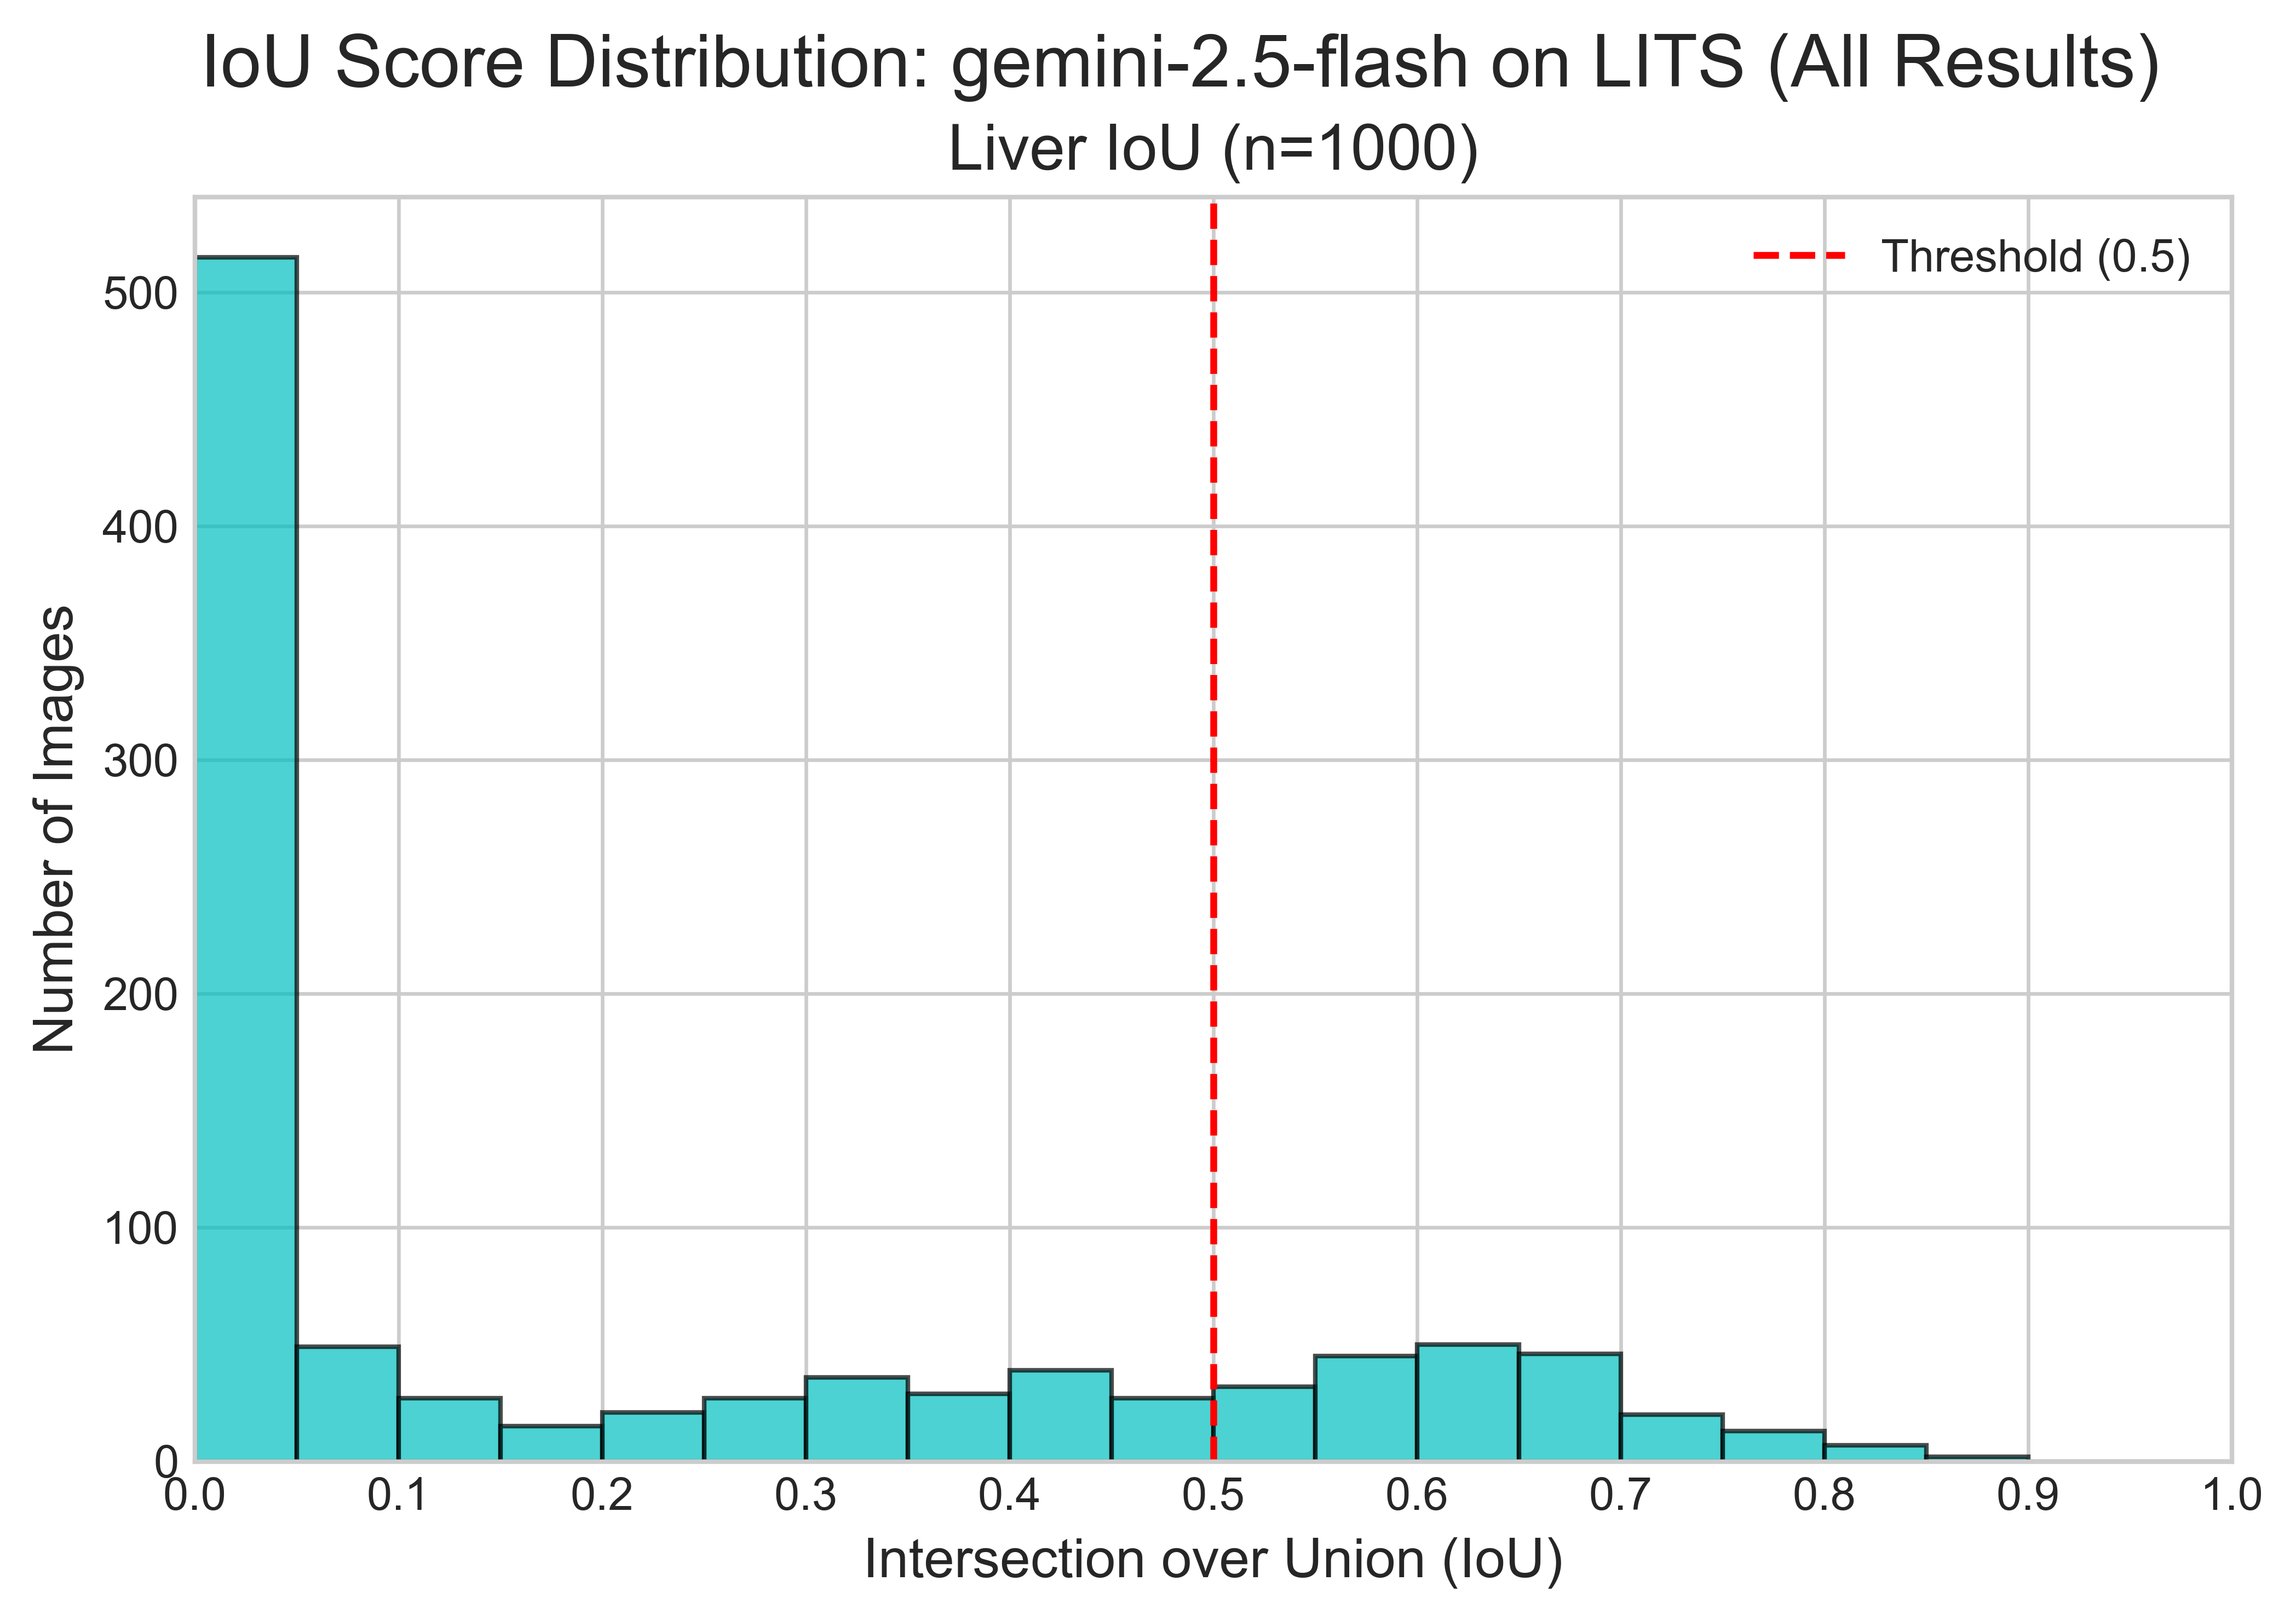

"\n✅ Evaluation complete. The report above summarizes the model's performance on the LITS dataset.\n"

In [12]:
# %% [markdown]
"""
# 04 Model Evaluation · **LITS Liver & Mass Segmentation**

*Last sync 02 Aug 2025*

This notebook evaluates the performance of the `gemini_seg` function for segmenting the liver and liver masses
from the LITS abdominal CT dataset. It systematically calculates and aggregates key
performance metrics by comparing the model's output against ground-truth data.

**Key Features (Adapted for LITS):**
- **Efficient Data Loading:** Uses the pre-processed `lits_df.csv` to find all positive cases, avoiding rescans.
- **Multithreaded Evaluation:** Runs multiple API requests in parallel to significantly speed up the evaluation process.
- **Dynamic Target Evaluation:** Can evaluate either "liver" or "liver mass" by changing a single configuration variable.
- **Core Performance Metrics:** Calculates Dice Score and Intersection over Union (IoU).
- **Flexible Analysis:** A toggle (`EXCLUDE_LOW_IOU_FROM_STATS`) allows metrics and plots to be generated for either all images or only successful detections.
- **Robust Failure Analysis:** Categorizes and saves lists of failed images (JSON errors, false negatives, low IoU) for detailed review.
- **Bootstrapped Confidence Intervals:** An optional toggle (`ENABLE_BOOTSTRAPPING`) enables the calculation of 95% confidence intervals for all key metrics.
- **Publication-Ready Outputs:** Saves a detailed JSON summary and a high-resolution (600 DPI) plot of the IoU distribution, all dynamically named.
- **Robust API Handling:** Includes rate limiting, client-side request timeouts, and disabled safety filters for medical content.
"""

# %%
# ---------- Preamble & Setup ----------
import sys, logging, os, subprocess, importlib.util, json, io, random, base64, dataclasses, time
from datetime import datetime
from pathlib import Path
from typing import Tuple, List, Dict, Optional
from concurrent.futures import ThreadPoolExecutor, as_completed, TimeoutError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageColor, UnidentifiedImageError
from tqdm import tqdm
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Evaluation notebook start.")

# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow", "google-genai", "pandas"):
    _ensure(extra)

# %%
# ---------- GenAI Client & Dataset Paths ----------
load_dotenv(find_dotenv(), override=False)

from google import genai
from google.genai import types
from google.genai.types import GenerateContentConfig, Part, ThinkingConfig

if not os.getenv("GOOGLE_API_KEY"):
    raise ValueError("GOOGLE_API_KEY not found. Ensure it is in your .env file.")

client = genai.Client()
logging.info("GenAI client initialized.")


# MODIFIED: Point to the LITS dataset directory.
dataset_dir = Path("data/LITS").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("LITS dataset found at %s", dataset_dir)

# %% [markdown]
"""
### Core Functions (Adapted for LITS)

This section includes the necessary functions for segmentation and evaluation, adapted for the LITS dataset.

**Key Modifications:**
- **`PROMPT`:** Made dynamic to accept either "liver" or "liver mass".
- **`parse_ground_truth_mask`:** Simplified to parse the binary PNG masks from the LITS dataset.
- **`gemini_seg`:** Includes safety settings to allow for "liver mass" segmentation.
"""

# %%
# ---------- Core Segmentation & Parsing Logic ----------

@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def parse_json(json_output: str) -> str:
    """Cleans the model's JSON output by removing markdown fencing."""
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line.strip() == "```json":
            json_content = "\n".join(lines[i+1:])
            closing_fence_index = json_content.find("```")
            if closing_fence_index != -1:
                json_content = json_content[:closing_fence_index]
            return json_content.strip()
    return json_output.strip()

def parse_segmentation_masks(
    predicted_str: str, *, img_height: int, img_width: int
) -> Tuple[List[SegmentationMask], bool]:
    """
    Parses the model's JSON output into a list of SegmentationMask objects.
    Returns the list of masks and a boolean indicating if JSON parsing was successful.
    """
    cleaned_json = parse_json(predicted_str)
    if not cleaned_json:
        logging.warning("Parsing model output resulted in an empty string.")
        return [], True # Technically not a JSON error, but an empty response.

    try:
        items = json.loads(cleaned_json)
        parse_success = True
    except json.JSONDecodeError as e:
        logging.error(f"Failed to decode JSON: {e}")
        logging.error(f"Problematic string after cleaning: {cleaned_json}")
        return [], False

    masks = []
    for item in items:
        try:
            abs_y0 = int(item["box_2d"][0] / 1000 * img_height)
            abs_x0 = int(item["box_2d"][1] / 1000 * img_width)
            abs_y1 = int(item["box_2d"][2] / 1000 * img_height)
            abs_x1 = int(item["box_2d"][3] / 1000 * img_width)

            if abs_y0 >= abs_y1 or abs_x0 >= abs_x1:
                continue

            label = item["label"].lower() # Standardize label to lowercase
            png_b64_str = item["mask"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            partial_mask_img = Image.open(io.BytesIO(png_bytes))

            bbox_height = abs_y1 - abs_y0
            bbox_width = abs_x1 - abs_x0
            resized_mask = partial_mask_img.resize((bbox_width, bbox_height), resample=Image.Resampling.BILINEAR)
            full_mask_np = np.zeros((img_height, img_width), dtype=np.uint8)
            full_mask_np[abs_y0:abs_y1, abs_x0:abs_x1] = np.array(resized_mask)

            masks.append(SegmentationMask(abs_y0, abs_x0, abs_y1, abs_x1, full_mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in JSON response: {item}. Error: {e}")
            continue
    return masks, parse_success

def parse_ground_truth_mask(mask_path: Path, label: str) -> list[SegmentationMask]:
    """
    Parses a LITS ground truth PNG file into a single SegmentationMask.
    The mask is a single-channel binary image.
    """
    try:
        mask_img = Image.open(mask_path).convert("L") # Ensure single channel grayscale
        mask_data = np.array(mask_img)
    except (FileNotFoundError, UnidentifiedImageError) as e:
        logging.error("Could not read ground truth mask file %s: %s", mask_path, e)
        return []

    # FIXED: Use > 0 to correctly binarize low-intensity masks.
    binary_mask_data = mask_data > 0

    if not np.any(binary_mask_data):
        return []

    rows, cols = np.where(binary_mask_data)
    y0, y1 = rows.min(), rows.max()
    x0, x1 = cols.min(), cols.max()
    full_mask_np = binary_mask_data.astype(np.uint8) * 255
    return [SegmentationMask(y0, x0, y1, x1, full_mask_np, label)]


def gemini_seg(image_obj: Image.Image, model_name: str, thinking_budget: int, prompt: str) -> Tuple[List[SegmentationMask], float, bool]:
    """
    Sends a PIL Image object to Gemini and returns segmentation masks, with a client-side timeout.
    """
    original_width, original_height = image_obj.size
    
    img_for_api = image_obj.copy()
    max_dim = 1024
    if img_for_api.height > max_dim or img_for_api.width > max_dim:
        img_for_api.thumbnail((max_dim, max_dim))

    with io.BytesIO() as img_byte_arr:
        img_for_api.save(img_byte_arr, format='PNG')
        img_bytes = img_byte_arr.getvalue()

    safety_settings=[
        types.SafetySetting(category=types.HarmCategory.HARM_CATEGORY_HARASSMENT, threshold=types.HarmBlockThreshold.BLOCK_NONE),
        types.SafetySetting(category=types.HarmCategory.HARM_CATEGORY_HATE_SPEECH, threshold=types.HarmBlockThreshold.BLOCK_NONE),
        types.SafetySetting(category=types.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT, threshold=types.HarmBlockThreshold.BLOCK_NONE),
        types.SafetySetting(category=types.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT, threshold=types.HarmBlockThreshold.BLOCK_NONE),
    ]

    gen_config = GenerateContentConfig(
        thinking_config=ThinkingConfig(thinking_budget=thinking_budget),
        temperature=0.5,
        safety_settings=safety_settings
    )
    image_part = Part.from_bytes(data=img_bytes, mime_type='image/png')
    text_part = Part(text=prompt)
    
    def do_api_call():
        return client.models.generate_content(
            model=model_name, contents=[image_part, text_part], config=gen_config
        )

    start_time = datetime.now()
    try:
        if ENABLE_REQUEST_TIMEOUT:
            with ThreadPoolExecutor(max_workers=1) as executor:
                future = executor.submit(do_api_call)
                response = future.result(timeout=REQUEST_TIMEOUT_SEC)
        else:
            response = do_api_call()
        
        latency = (datetime.now() - start_time).total_seconds()
        masks, parse_success = parse_segmentation_masks(
            response.text, img_height=original_height, img_width=original_width
        )
        return masks, latency, parse_success

    except TimeoutError:
        logging.error(f"API call timed out after {REQUEST_TIMEOUT_SEC} seconds.")
        return [], 0.0, False
    except Exception as e:
        logging.error(f"An error occurred during the gemini_seg function.", exc_info=True)
        return [], 0.0, False

def save_prediction_details(masks: List[SegmentationMask], output_path: Path):
    """Saves the detailed contents of SegmentationMask objects to a JSON file."""
    if not masks:
        output_path.write_text(json.dumps([]))
        return

    results_to_save = []
    for mask_obj in masks:
        pil_img = Image.fromarray(mask_obj.mask)
        with io.BytesIO() as buffer:
            pil_img.save(buffer, format="PNG")
            png_bytes = buffer.getvalue()
        b64_string = base64.b64encode(png_bytes).decode('utf-8')
        results_to_save.append({
            "label": mask_obj.label,
            "box_2d_absolute": [mask_obj.y0, mask_obj.x0, mask_obj.y1, mask_obj.x1],
            "mask_b64": f"data:image/png;base64,{b64_string}"
        })
    with open(output_path, 'w') as f:
        json.dump(results_to_save, f, indent=2)

# %% [markdown]
"""
### Metric Calculation Utilities

These functions implement the formulas for Intersection over Union (IoU), the Dice Coefficient, and bootstrapping for confidence intervals.
"""

# %%
# ---------- Metric Calculation Functions ----------

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 1.0
    return np.sum(intersection) / np.sum(union)

def calculate_dice(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates the Dice Coefficient for boolean masks."""
    intersection = np.sum(np.logical_and(y_true, y_pred))
    denominator = np.sum(y_true) + np.sum(y_pred)
    if denominator == 0: return 1.0
    return (2. * intersection) / (denominator + 1e-7)

def calculate_bootstrap_ci(data: List[float], n_resamples: int = 1000) -> Tuple[float, float]:
    """Calculates the 95% confidence interval for a list of numbers using bootstrapping."""
    if not data or len(data) < 2: return 0.0, 0.0
    bootstrapped_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_resamples)]
    return np.percentile(bootstrapped_means, 2.5), np.percentile(bootstrapped_means, 97.5)

# %% [markdown]
"""
### Evaluation Execution

This is the main execution block. It will:
1.  Load the `lits_df.csv` file.
2.  Filter for positive cases based on the `SEGMENTATION_TARGET`.
3.  Randomly sample a specified number of images (`NUM_IMAGES_TO_TEST`).
4.  Use a `ThreadPoolExecutor` to run the evaluation on multiple images in parallel.
5.  For each image, it calls `gemini_seg`, parses the ground truth, calculates metrics, and categorizes failures.
6.  Collects all results for final aggregation and reporting.
"""

# %%
# ---------- Main Evaluation Loop ----------

# <<< --- PARAMETERS TO CONTROL THE EVALUATION --- >>>
MODEL_NAME = "gemini-2.5-flash"
SEGMENTATION_TARGET = "liver" # Options: "liver", "liver mass"
THINKING_BUDGET = 0
NUM_IMAGES_TO_TEST = 1000 # Set to None or 0 to test all images
MAX_WORKERS = 8 # Number of parallel threads for evaluation
SAVE_PREDICTIONS = True
ENABLE_BOOTSTRAPPING = True
ENABLE_RATE_LIMITING = False
RATE_LIMIT_DELAY_SEC = 9
ENABLE_REQUEST_TIMEOUT = True
REQUEST_TIMEOUT_SEC = 300
LOW_IOU_THRESHOLD = 0.5
EXCLUDE_LOW_IOU_FROM_STATS = True # If True, stats only use runs with IoU >= threshold.

model_name_safe = MODEL_NAME.replace("/", "_")
target_safe = SEGMENTATION_TARGET.replace(" ", "_")
logging.info(f"Starting evaluation run for model: {MODEL_NAME} on LITS dataset for target: {SEGMENTATION_TARGET}.")

# --- Define Dynamic Prompt ---
PROMPT = (
    f'In this slice of an abdominal CT, give the segmentation mask for the {SEGMENTATION_TARGET}. '
    'Output a JSON list of segmentation masks where each entry contains the 2D bounding box in the key "box_2d", '
    'the segmentation mask in key "mask", and the text label in the key "label". '
    f'Use the label "{SEGMENTATION_TARGET}".'
)

# --- Load and Prepare Data from CSV ---
def correct_path(p: str, base_dir: Path) -> Path:
    parts = Path(p).parts
    if len(parts) >= 2:
        return base_dir / parts[-2] / parts[-1]
    return Path(p)

lits_csv_path = dataset_dir / "lits_df.csv"
logging.info("Loading and processing %s", lits_csv_path.name)
lits_df = pd.read_csv(lits_csv_path)

path_cols = ['filepath', 'liver_maskpath', 'tumor_maskpath']
for col in path_cols:
    lits_df[col] = lits_df[col].apply(lambda x: correct_path(x, dataset_dir))

if SEGMENTATION_TARGET == "liver":
    mask_path_col = 'liver_maskpath'
    mask_empty_col = 'liver_mask_empty'
elif SEGMENTATION_TARGET == "liver mass":
    mask_path_col = 'tumor_maskpath'
    mask_empty_col = 'tumor_mask_empty'
else:
    raise ValueError(f"Invalid SEGMENTATION_TARGET: {SEGMENTATION_TARGET}")

logging.info("Identifying positive cases based on '%s' column...", mask_empty_col)
positive_df = lits_df[lits_df[mask_empty_col] == True]

images_to_evaluate_pairs = []
for _, row in positive_df.iterrows():
    img_path = row['filepath']
    mask_path = row[mask_path_col]
    if img_path.exists() and mask_path.exists():
        images_to_evaluate_pairs.append((img_path, mask_path))

logging.info(f"Found {len(images_to_evaluate_pairs)} total positive cases for '{SEGMENTATION_TARGET}'.")

# --- Create Model-Specific Predictions Directory ---
if SAVE_PREDICTIONS:
    predictions_dir = dataset_dir / f"predictions_{target_safe}_{model_name_safe}"
    predictions_dir.mkdir(exist_ok=True)
    logging.info(f"Detailed predictions will be saved to: {predictions_dir}")

# --- Prepare Evaluation Set ---
random.seed(42)
random.shuffle(images_to_evaluate_pairs)
if NUM_IMAGES_TO_TEST is not None and NUM_IMAGES_TO_TEST > 0:
    images_to_evaluate_pairs = images_to_evaluate_pairs[:min(NUM_IMAGES_TO_TEST, len(images_to_evaluate_pairs))]
logging.info(f"Will evaluate a sample of {len(images_to_evaluate_pairs)} images using up to {MAX_WORKERS} threads.")

# --- Multithreaded Evaluation Worker ---
def evaluate_single_image(img_path: Path, mask_path: Path) -> Dict:
    """Worker function to process and evaluate a single image."""
    try:
        original_image = Image.open(img_path)
        predicted_masks, latency, parse_success = gemini_seg(original_image, MODEL_NAME, THINKING_BUDGET, PROMPT)

        if SAVE_PREDICTIONS:
            prediction_output_path = predictions_dir / f"{img_path.stem}.json"
            save_prediction_details(predicted_masks, prediction_output_path)

        gt_masks = parse_ground_truth_mask(mask_path, SEGMENTATION_TARGET)
        gt_mask_np = gt_masks[0].mask if gt_masks else np.zeros((original_image.height, original_image.width), dtype=np.uint8)
        
        # Merge all predicted masks for the target label into one composite mask
        pred_mask_np = np.zeros_like(gt_mask_np)
        for p_mask in predicted_masks:
            if p_mask.label.lower() == SEGMENTATION_TARGET.lower():
                pred_mask_np = np.logical_or(pred_mask_np, p_mask.mask > 127)
        pred_mask_np = pred_mask_np.astype(np.uint8) * 255

        iou_score = calculate_iou(gt_mask_np > 0, pred_mask_np > 127)
        dice_score = calculate_dice(gt_mask_np > 0, pred_mask_np > 127)

        failure_type = "none"
        if not parse_success:
            failure_type = "json"
        elif not np.any(pred_mask_np):
            failure_type = "fn"
        elif iou_score < LOW_IOU_THRESHOLD:
            failure_type = "low_iou"

        return {
            "image_path": img_path.name, "latency_sec": latency, "parse_success": parse_success,
            "iou": iou_score, "dice": dice_score,
            "failure_type": failure_type
        }
    except Exception as e:
        logging.error(f"An unexpected error occurred while processing {img_path.name}", exc_info=True)
        return {
            "image_path": img_path.name, "latency_sec": 0, "parse_success": False,
            "iou": 0, "dice": 0, "failure_type": "processing_error"
        }

# --- Execute Evaluation in Parallel ---
all_results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_path = {executor.submit(evaluate_single_image, img_p, mask_p): img_p for img_p, mask_p in images_to_evaluate_pairs}
    for future in tqdm(as_completed(future_to_path), total=len(images_to_evaluate_pairs), desc=f"Evaluating {target_safe}"):
        all_results.append(future.result())
        if ENABLE_RATE_LIMITING:
            time.sleep(RATE_LIMIT_DELAY_SEC)

logging.info("Evaluation loop complete.")

# --- Aggregate results and failures ---
evaluation_results = []
json_failures, fn_failures, low_iou_failures = [], [], []
for result in all_results:
    evaluation_results.append(result)
    if result["failure_type"] == "json":
        json_failures.append(result["image_path"])
    elif result["failure_type"] == "fn":
        fn_failures.append(result["image_path"])
    elif result["failure_type"] == "low_iou":
        low_iou_failures.append(result["image_path"])

# %% [markdown]
"""
### Failure Analysis & Reporting

This section saves the lists of failed images to model-specific text files for easier manual review. Failures are categorized by type (JSON error, false negative, low IoU).
"""

# %%
# ---------- Save Failure Lists to Files ----------
def save_failure_list(failure_list: List[str], failure_type: str, target_name: str, model_name: str):
    """Saves a list of failed image names to a text file."""
    if failure_list:
        failure_path = dataset_dir / f"failures_{failure_type}_{target_name}_{model_name}.txt"
        logging.info(f"Saving {len(failure_list)} {failure_type} failures to {failure_path}")
        failure_path.write_text("\n".join(failure_list))

save_failure_list(json_failures, "json", target_safe, model_name_safe)
save_failure_list(fn_failures, "fn", target_safe, model_name_safe)
save_failure_list(low_iou_failures, "low_iou", target_safe, model_name_safe)

# %% [markdown]
"""
### Results Summary

The following report aggregates the results from the evaluation run and saves a copy to a dynamically named JSON file.
"""

# %%
# ---------- Aggregate, Display, and Save Results ----------

if evaluation_results:
    df = pd.DataFrame(evaluation_results)

    if EXCLUDE_LOW_IOU_FROM_STATS:
        logging.info(f"Excluding cases with IoU < {LOW_IOU_THRESHOLD} from stats.")
        runs_for_stats = df[df['iou'] >= LOW_IOU_THRESHOLD]
    else:
        logging.info("Including all cases (even IoU=0) in stats.")
        runs_for_stats = df

    mean_iou = runs_for_stats['iou'].mean()
    mean_dice = runs_for_stats['dice'].mean()

    valid_latencies = df[df['latency_sec'] > 0]['latency_sec']
    mean_latency = valid_latencies.mean() if not valid_latencies.empty else 0
    total_runs = len(df)
    parse_success_rate = df['parse_success'].mean() * 100

    iou_ci, dice_ci, latency_ci = [(0,0)]*3
    if ENABLE_BOOTSTRAPPING:
        logging.info("Calculating 95%% CIs with 1000-fold bootstrapping...")
        iou_ci = calculate_bootstrap_ci(runs_for_stats['iou'].tolist())
        dice_ci = calculate_bootstrap_ci(runs_for_stats['dice'].tolist())
        latency_ci = calculate_bootstrap_ci(valid_latencies.tolist())
        logging.info("CI calculation complete.")

    print("---" * 15)
    print(f"         GenAI Segmentation Evaluation Report: {MODEL_NAME} on LITS")
    print(f"         Target: {SEGMENTATION_TARGET.title()}")
    print("---" * 15)
    print(f"Total Images Evaluated: {total_runs}")
    print(f"IoU Threshold for Success: {LOW_IOU_THRESHOLD}")
    print(f"Exclude Low IoU from Stats: {EXCLUDE_LOW_IOU_FROM_STATS}")
    
    print("\n--- Performance Metrics ---")
    print(f"Mean IoU ({SEGMENTATION_TARGET.title()}):   {mean_iou:.4f} (95% CI: {iou_ci[0]:.4f} - {iou_ci[1]:.4f}) on {len(runs_for_stats)} images")
    print(f"Mean Dice ({SEGMENTATION_TARGET.title()}):  {mean_dice:.4f} (95% CI: {dice_ci[0]:.4f} - {dice_ci[1]:.4f})")
    
    print("\n--- Operational Metrics ---")
    print(f"Mean API Latency:        {mean_latency:.2f}s (95% CI: {latency_ci[0]:.2f}s - {latency_ci[1]:.2f}s)")
    print(f"JSON Parse Success:      {parse_success_rate:.1f}%")

    print("\n--- Failure Analysis (based on full dataset) ---")
    print(f"JSON Failures:           {len(json_failures)} ({len(json_failures)/total_runs:.1%})")
    print(f"False Negatives:         {len(fn_failures)} ({len(fn_failures)/total_runs:.1%})")
    print(f"Low IoU:                 {len(low_iou_failures)} ({len(low_iou_failures)/total_runs:.1%})")
    print("---" * 15)

    summary_data = {
        "run_timestamp": datetime.now().isoformat(),
        "total_images_evaluated": total_runs,
        "settings": { "model_name": MODEL_NAME, "segmentation_target": SEGMENTATION_TARGET, "thinking_budget": THINKING_BUDGET, "low_iou_threshold": LOW_IOU_THRESHOLD, "exclude_low_iou_from_stats": EXCLUDE_LOW_IOU_FROM_STATS },
        "performance_metrics": {
            f"mean_iou_{target_safe}": mean_iou, f"mean_iou_{target_safe}_95_ci": iou_ci,
            f"mean_dice_{target_safe}": mean_dice, f"mean_dice_{target_safe}_95_ci": dice_ci,
        },
        "operational_metrics": { "mean_latency_sec": mean_latency, "mean_latency_95_ci": latency_ci, "json_parse_success_rate_percent": parse_success_rate, },
        "failure_counts": {
            "json_parsing": len(json_failures),
            "false_negative": len(fn_failures),
            "low_iou": len(low_iou_failures),
        }
    }
    summary_path = dataset_dir / f"evaluation_summary_{target_safe}_{model_name_safe}.json"
    with open(summary_path, 'w') as f:
        json.dump(summary_data, f, indent=4)
    logging.info(f"Saved evaluation summary to {summary_path}")

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=600)
    fig.suptitle(f'IoU Score Distribution: {MODEL_NAME} on LITS (All Results)', fontsize=16)

    ax.hist(df['iou'], bins=20, range=(0,1), edgecolor='black', alpha=0.7, color='c')
    ax.set_title(f"{SEGMENTATION_TARGET.title()} IoU (n={len(df)})", fontsize=14)
    ax.set_xlabel('Intersection over Union (IoU)', fontsize=12)
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.axvline(LOW_IOU_THRESHOLD, color='r', linestyle='--', label=f'Threshold ({LOW_IOU_THRESHOLD})')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

    plot_path = dataset_dir / f"iou_distribution_{target_safe}_{model_name_safe}.png"
    plt.savefig(plot_path, bbox_inches='tight')
    logging.info(f"Saved high-resolution IoU plot to {plot_path}")
    plt.show()
else:
    print("No evaluation results were generated.")

# %% [markdown]
"""
✅ Evaluation complete. The report above summarizes the model's performance on the LITS dataset.
"""


# Case Plotting

2025-08-02 15:42:43 — INFO — LITS dataset found at D:\Projects\gemini_image_segmentation\data\LITS
2025-08-02 15:42:43 — INFO — IMAGE_TO_VISUALIZE not set. Searching for a high_iou case for model 'gemini-2.5-flash' and target 'liver'...
2025-08-02 15:42:44 — INFO — Found case: 'volume-102_483.png'. Visualizing...
2025-08-02 15:42:44 — INFO — Loading original image: volume-102_483.png
2025-08-02 15:42:44 — INFO — Loading ground truth: segmentation-102_livermask_483.png
2025-08-02 15:42:44 — INFO — Loading prediction for model 'gemini-2.5-flash' from cache: volume-102_483.json


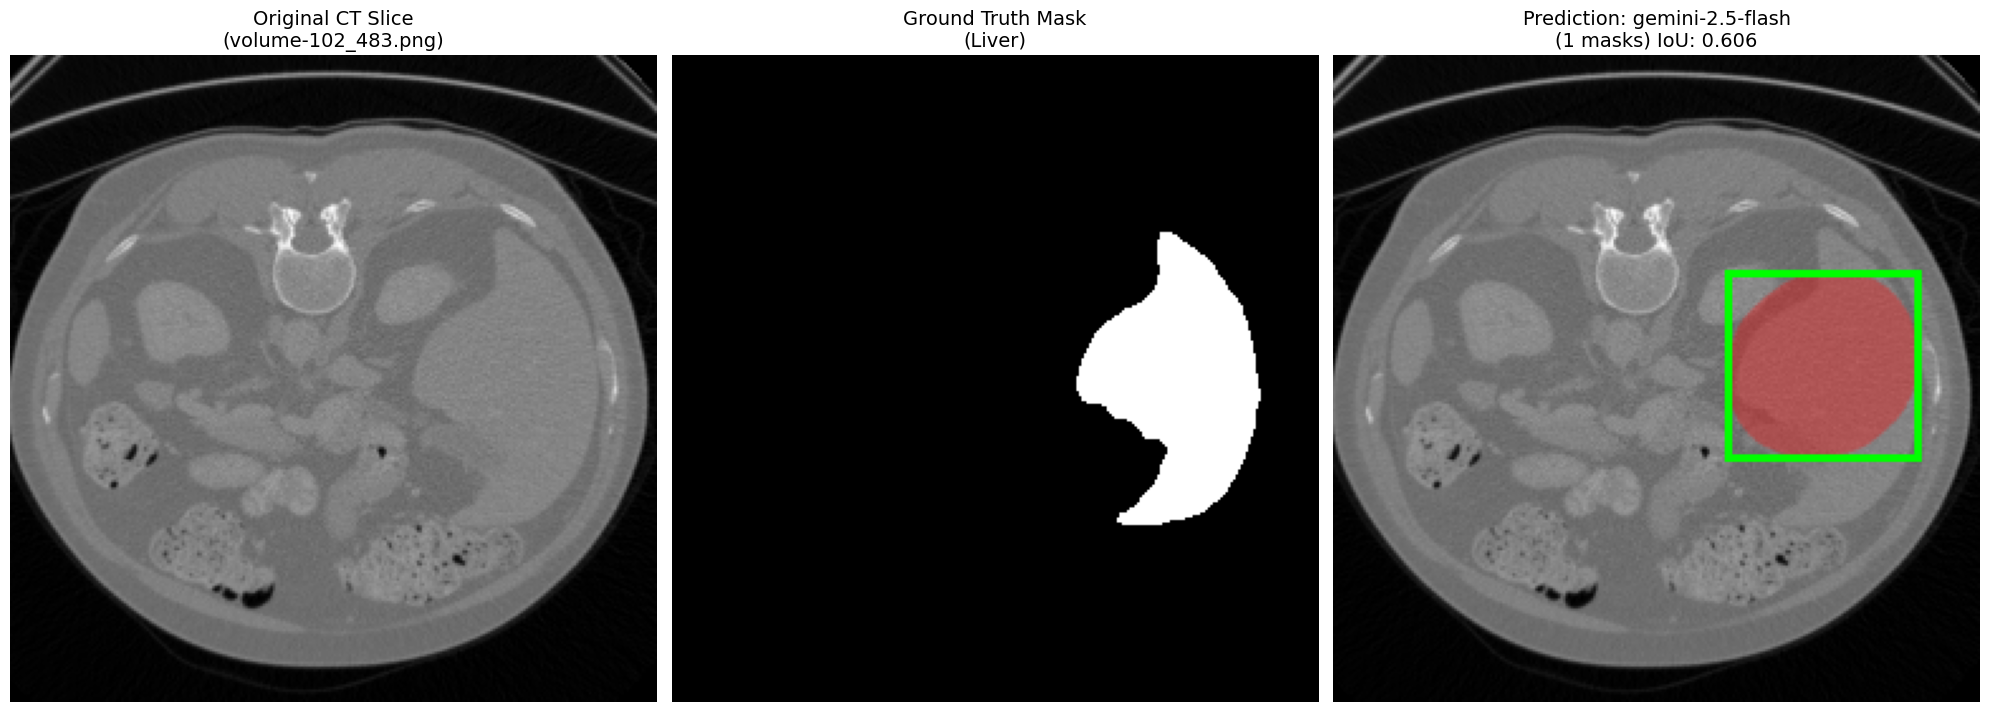

In [7]:
# %% [markdown]
"""
# 05 Qualitative Analysis (LITS)

*Last sync 02 Aug 2025*

This notebook provides tools to perform a qualitative check on the model's output from a previous evaluation run on the LITS dataset. It loads a cached prediction from the model-specific `predictions_<target>_<model_name>/` directory and displays a three-panel comparison for any given image.

**Instructions:**
- Ensure you have run the `04_Model_Evaluation_LITS` notebook first with `SAVE_PREDICTIONS = True`.
- Set the `MODEL_TO_VISUALIZE`, `TARGET_TO_VISUALIZE`, and `VISUALIZATION_TYPE` variables in the last cell.
- To visualize a specific image, set the `IMAGE_TO_VISUALIZE` variable to the desired filename (e.g., `volume-97_335.png`).
- If you leave `IMAGE_TO_VISUALIZE` as `None`, the script will automatically find and display a case matching your criteria.
"""

# %%
# ---------- Preamble & Setup ----------
import os, json, base64, dataclasses, logging, io
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, UnidentifiedImageError
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

# %%
# ---------- Dataset Path & Helper Functions ----------
# MODIFIED: Point to the LITS dataset directory.
dataset_dir = Path("data/LITS").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("LITS dataset found at %s", dataset_dir)


@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0:
        return 1.0 # If both masks are empty, it's a perfect match.
    iou_score = np.sum(intersection) / np.sum(union)
    return iou_score

def load_prediction_from_cache(prediction_path: Path) -> List[SegmentationMask]:
    """Loads and parses a cached prediction JSON file into SegmentationMask objects."""
    if not prediction_path.exists():
        logging.error(f"Prediction cache file not found: {prediction_path}")
        return []
    
    with open(prediction_path, 'r') as f:
        try:
            items = json.load(f)
        except json.JSONDecodeError:
            logging.error(f"Could not decode JSON from cached file: {prediction_path}")
            return []

    masks = []
    for item in items:
        try:
            y0, x0, y1, x1 = item["box_2d_absolute"]
            label = item["label"]
            
            png_b64_str = item["mask_b64"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            mask_img = Image.open(io.BytesIO(png_bytes))
            mask_np = np.array(mask_img)

            masks.append(SegmentationMask(y0, x0, y1, x1, mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in cached prediction: {item}. Error: {e}")
            continue
    return masks

def find_complete_case(model_name: str, target_name: str, visualization_type: str, iou_threshold: float) -> str | None:
    """
    Scans a model's predictions directory and finds the first case that matches
    the desired visualization type (high or low IoU).
    """
    model_name_safe = model_name.replace("/", "_")
    target_name_safe = target_name.replace(" ", "_")
    predictions_dir = dataset_dir / f"predictions_{target_name_safe}_{model_name_safe}"
    
    if not predictions_dir.exists():
        logging.error(f"Predictions directory not found for model '{model_name}' and target '{target_name}': {predictions_dir}")
        return None

    lits_csv_path = dataset_dir / "lits_df.csv"
    if not lits_csv_path.exists():
        logging.error(f"Master CSV not found: {lits_csv_path}")
        return None
    lits_df = pd.read_csv(lits_csv_path)
    lits_df['filename'] = lits_df['filepath'].apply(lambda p: Path(p).name)
    lits_df = lits_df.set_index('filename')

    def correct_path(p: str, base_dir: Path) -> Path:
        parts = Path(p).parts
        if len(parts) >= 2:
            return base_dir / parts[-2] / parts[-1]
        return Path(p)

    for pred_file in sorted(predictions_dir.glob("*.json")):
        image_filename = f"{pred_file.stem}.png"
        if image_filename not in lits_df.index:
            continue
        
        case_row = lits_df.loc[image_filename]
        
        if target_name == "liver":
            gt_mask_path = correct_path(case_row['liver_maskpath'], dataset_dir)
        else:
            gt_mask_path = correct_path(case_row['tumor_maskpath'], dataset_dir)
            
        if not gt_mask_path.exists():
            continue

        gt_mask_pil = Image.open(gt_mask_path).convert("L")
        # FIXED: Use > 0 to correctly binarize low-intensity masks
        gt_mask_np = np.array(gt_mask_pil) > 0
        
        predicted_masks = load_prediction_from_cache(pred_file)
        
        # Skip false negatives completely, as they have an IoU of 0 and aren't interesting for qualitative review.
        if not predicted_masks:
            continue

        combined_pred_mask_np = np.zeros_like(gt_mask_np, dtype=bool)
        for seg_mask in predicted_masks:
            if seg_mask.label.lower() == target_name.lower():
                combined_pred_mask_np = np.logical_or(combined_pred_mask_np, seg_mask.mask > 127)
        
        iou_val = calculate_iou(gt_mask_np, combined_pred_mask_np)

        if visualization_type == 'high_iou' and iou_val >= iou_threshold:
            return image_filename
        # FIXED: Find cases where a mask was produced (IoU > 0) but was poor (IoU < threshold).
        elif visualization_type == 'low_iou' and 0 < iou_val < iou_threshold:
            return image_filename
            
    return None

def visualize_single_case(image_name: str, model_name: str, target_name: str):
    """
    Generates and displays a 3-panel plot comparing the original image,
    ground truth mask, and the model's predicted mask overlay from cached files
    for the LITS dataset.
    """
    model_name_safe = model_name.replace("/", "_")
    target_name_safe = target_name.replace(" ", "_")

    lits_csv_path = dataset_dir / "lits_df.csv"
    if not lits_csv_path.exists():
        logging.error(f"Master CSV not found: {lits_csv_path}")
        return
    lits_df = pd.read_csv(lits_csv_path)
    lits_df['filename'] = lits_df['filepath'].apply(lambda p: Path(p).name)
    
    case_row = lits_df[lits_df['filename'] == image_name]
    if case_row.empty:
        logging.error(f"Could not find '{image_name}' in {lits_csv_path.name}")
        return
    case_row = case_row.iloc[0]

    def correct_path(p: str, base_dir: Path) -> Path:
        parts = Path(p).parts
        if len(parts) >= 2:
            return base_dir / parts[-2] / parts[-1]
        return Path(p)

    image_path = correct_path(case_row['filepath'], dataset_dir)
    
    if target_name == "liver":
        gt_mask_path = correct_path(case_row['liver_maskpath'], dataset_dir)
    elif target_name == "liver mass":
        gt_mask_path = correct_path(case_row['tumor_maskpath'], dataset_dir)
    else:
        logging.error(f"Invalid target name: {target_name}")
        return

    prediction_path = dataset_dir / f"predictions_{target_name_safe}_{model_name_safe}" / f"{Path(image_name).stem}.json"
    
    if not image_path.exists() or not prediction_path.exists():
        logging.error(f"Missing file. Image: {image_path.exists()}, Prediction: {prediction_path.exists()}")
        return

    logging.info(f"Loading original image: {image_path.name}")
    original_image = Image.open(image_path).convert("RGBA")
    
    logging.info(f"Loading ground truth: {gt_mask_path.name}")
    if gt_mask_path.exists():
        gt_mask_pil = Image.open(gt_mask_path).convert("L")
        # FIXED: Use > 0 to correctly binarize low-intensity masks
        gt_mask_np = np.array(gt_mask_pil) > 0
        highlighted_mask_np = np.where(gt_mask_np, 255, 0).astype(np.uint8)
        highlighted_gt_mask_pil = Image.fromarray(highlighted_mask_np)
    else:
        logging.warning(f"Ground truth mask not found: {gt_mask_path}")
        highlighted_gt_mask_pil = Image.new("L", original_image.size, 0)
        gt_mask_np = np.zeros(original_image.size, dtype=bool)

    logging.info(f"Loading prediction for model '{model_name}' from cache: {prediction_path.name}")
    predicted_masks = load_prediction_from_cache(prediction_path)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    plt.style.use('default')

    axes[0].imshow(original_image, cmap='gray')
    axes[0].set_title(f"Original CT Slice\n({image_name})", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(highlighted_gt_mask_pil, cmap='gray')
    axes[1].set_title(f"Ground Truth Mask\n({target_name.title()})", fontsize=14)
    axes[1].axis('off')

    overlay_image = original_image.copy()
    title = f"Prediction: {model_name}"
    if not predicted_masks:
        title = f"Prediction: {model_name}\n(No Mask Found)"
    else:
        combined_pred_mask_np = np.zeros_like(gt_mask_np, dtype=bool)
        for seg_mask in predicted_masks:
            if seg_mask.label.lower() == target_name.lower():
                pred_mask_binary = seg_mask.mask > 127
                combined_pred_mask_np = np.logical_or(combined_pred_mask_np, pred_mask_binary)
        
        iou_val = calculate_iou(gt_mask_np, combined_pred_mask_np)
        title = f"Prediction: {model_name}\n({len(predicted_masks)} masks) IoU: {iou_val:.3f}"

        mask_color = (255, 0, 0, 90)
        box_color = (0, 255, 0)
        
        for mask_obj in predicted_masks:
            if mask_obj.label.lower() == target_name.lower():
                mask_img_pil = Image.fromarray(mask_obj.mask).convert("L")
                colored_mask = Image.new("RGBA", original_image.size)
                colored_mask.paste(mask_color, mask=mask_img_pil)
                overlay_image = Image.alpha_composite(overlay_image, colored_mask)
                draw = ImageDraw.Draw(overlay_image)
                draw.rectangle([mask_obj.x0, mask_obj.y0, mask_obj.x1, mask_obj.y1], outline=box_color, width=3)

    axes[2].imshow(overlay_image, cmap='gray')
    axes[2].set_title(title, fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# %% [markdown]
"""
### Visualize a Specific Image

To use this notebook, modify the variables below.
"""

# %%
# ---------- Specify Model and Image, then Run Visualization ----------

# <<< --- REQUIRED: Set the model name you want to visualize --- >>>
MODEL_TO_VISUALIZE = "gemini-2.5-flash"

# <<< --- REQUIRED: Set the target you want to visualize --- >>>
TARGET_TO_VISUALIZE = "liver" # Options: "liver", "liver mass"

# <<< --- REQUIRED: Set the type of result you want to see --- >>>
VISUALIZATION_TYPE = 'high_iou' # Options: 'high_iou', 'low_iou'
LOW_IOU_THRESHOLD = 0.5 # Must match the threshold used in the evaluation script

# <<< --- OPTIONAL: Set a specific filename to visualize --- >>>
IMAGE_TO_VISUALIZE = None # e.g., "volume-97_335.png"

# --- Find and Visualize a Case ---
if not IMAGE_TO_VISUALIZE:
    logging.info(f"IMAGE_TO_VISUALIZE not set. Searching for a {VISUALIZATION_TYPE} case for model '{MODEL_TO_VISUALIZE}' and target '{TARGET_TO_VISUALIZE}'...")
    IMAGE_TO_VISUALIZE = find_complete_case(MODEL_TO_VISUALIZE, TARGET_TO_VISUALIZE, VISUALIZATION_TYPE, LOW_IOU_THRESHOLD)
    if IMAGE_TO_VISUALIZE:
        logging.info(f"Found case: '{IMAGE_TO_VISUALIZE}'. Visualizing...")
    else:
        # FIXED: Corrected typo in logging message
        logging.error(f"Could not find any {VISUALIZATION_TYPE} case for model '{MODEL_TO_VISUALIZE}' and target '{TARGET_TO_VISUALIZE}'.")
        logging.error("Please ensure you have run the `04_Model_Evaluation_LITS` notebook for this model and target.")

if IMAGE_TO_VISUALIZE:
    visualize_single_case(IMAGE_TO_VISUALIZE, MODEL_TO_VISUALIZE, TARGET_TO_VISUALIZE)


# Performance Metrics Re-Evaluation

TODO: Not confirmed to be working yet

2025-08-01 15:04:37 — INFO — Re-analysis notebook start.
2025-08-01 15:04:37 — INFO — Installing python-dotenv (missing)
2025-08-01 15:04:38 — INFO — Installing Pillow (missing)
2025-08-01 15:04:39 — INFO — REFUGE2 dataset found at D:\Projects\gemini_image_segmentation\data\REFUGE2
2025-08-01 15:04:39 — INFO — Found 1200 cached predictions for model 'gemini-2.5-flash-lite'.
2025-08-01 15:04:39 — INFO — Starting re-analysis with up to 12 threads.


Re-analyzing gemini-2.5-flash-lite:   0%|          | 0/1200 [00:00<?, ?it/s]

2025-08-01 15:05:57 — INFO — Excluding cases with IoU < 0.5 from stats calculations.
2025-08-01 15:05:57 — INFO — Saved re-analysis summary to D:\Projects\gemini_image_segmentation\data\REFUGE2\reanalysis_summary_gemini-2.5-flash-lite_thresh_0.5.json


---------------------------------------------
       Re-Analysis Report: gemini-2.5-flash-lite on REFUGE2
---------------------------------------------
Total Cached Predictions Analyzed: 1200
New IoU Threshold for Success:     0.5
Excluding Low IoU from Stats:    True

--- Performance Metrics ---
Mean IoU (Disc):      0.6694 (95% CI: 0.6587 - 0.6798) on 342 images
Mean IoU (Cup):       0.6178 (95% CI: 0.5998 - 0.6388) on 77 images
Mean Dice (Disc):     0.7974 (95% CI: 0.7895 - 0.8055)
Mean Dice (Cup):      0.7605 (95% CI: 0.7466 - 0.7751)

--- Clinical Metric ---
vCDR MAE:             0.2259 (95% CI: 0.2172 - 0.2341)

--- Failure Analysis (New Threshold) ---
False Negatives (Disc / Cup): 11 (0.9%) / 444 (37.0%)
Low IoU Failures (Disc / Cup): 847 (70.6%) / 679 (56.6%)
---------------------------------------------


2025-08-01 15:05:59 — INFO — Saved re-analysis IoU plot to D:\Projects\gemini_image_segmentation\data\REFUGE2\reanalysis_iou_dist_gemini-2.5-flash-lite_thresh_0.5.png


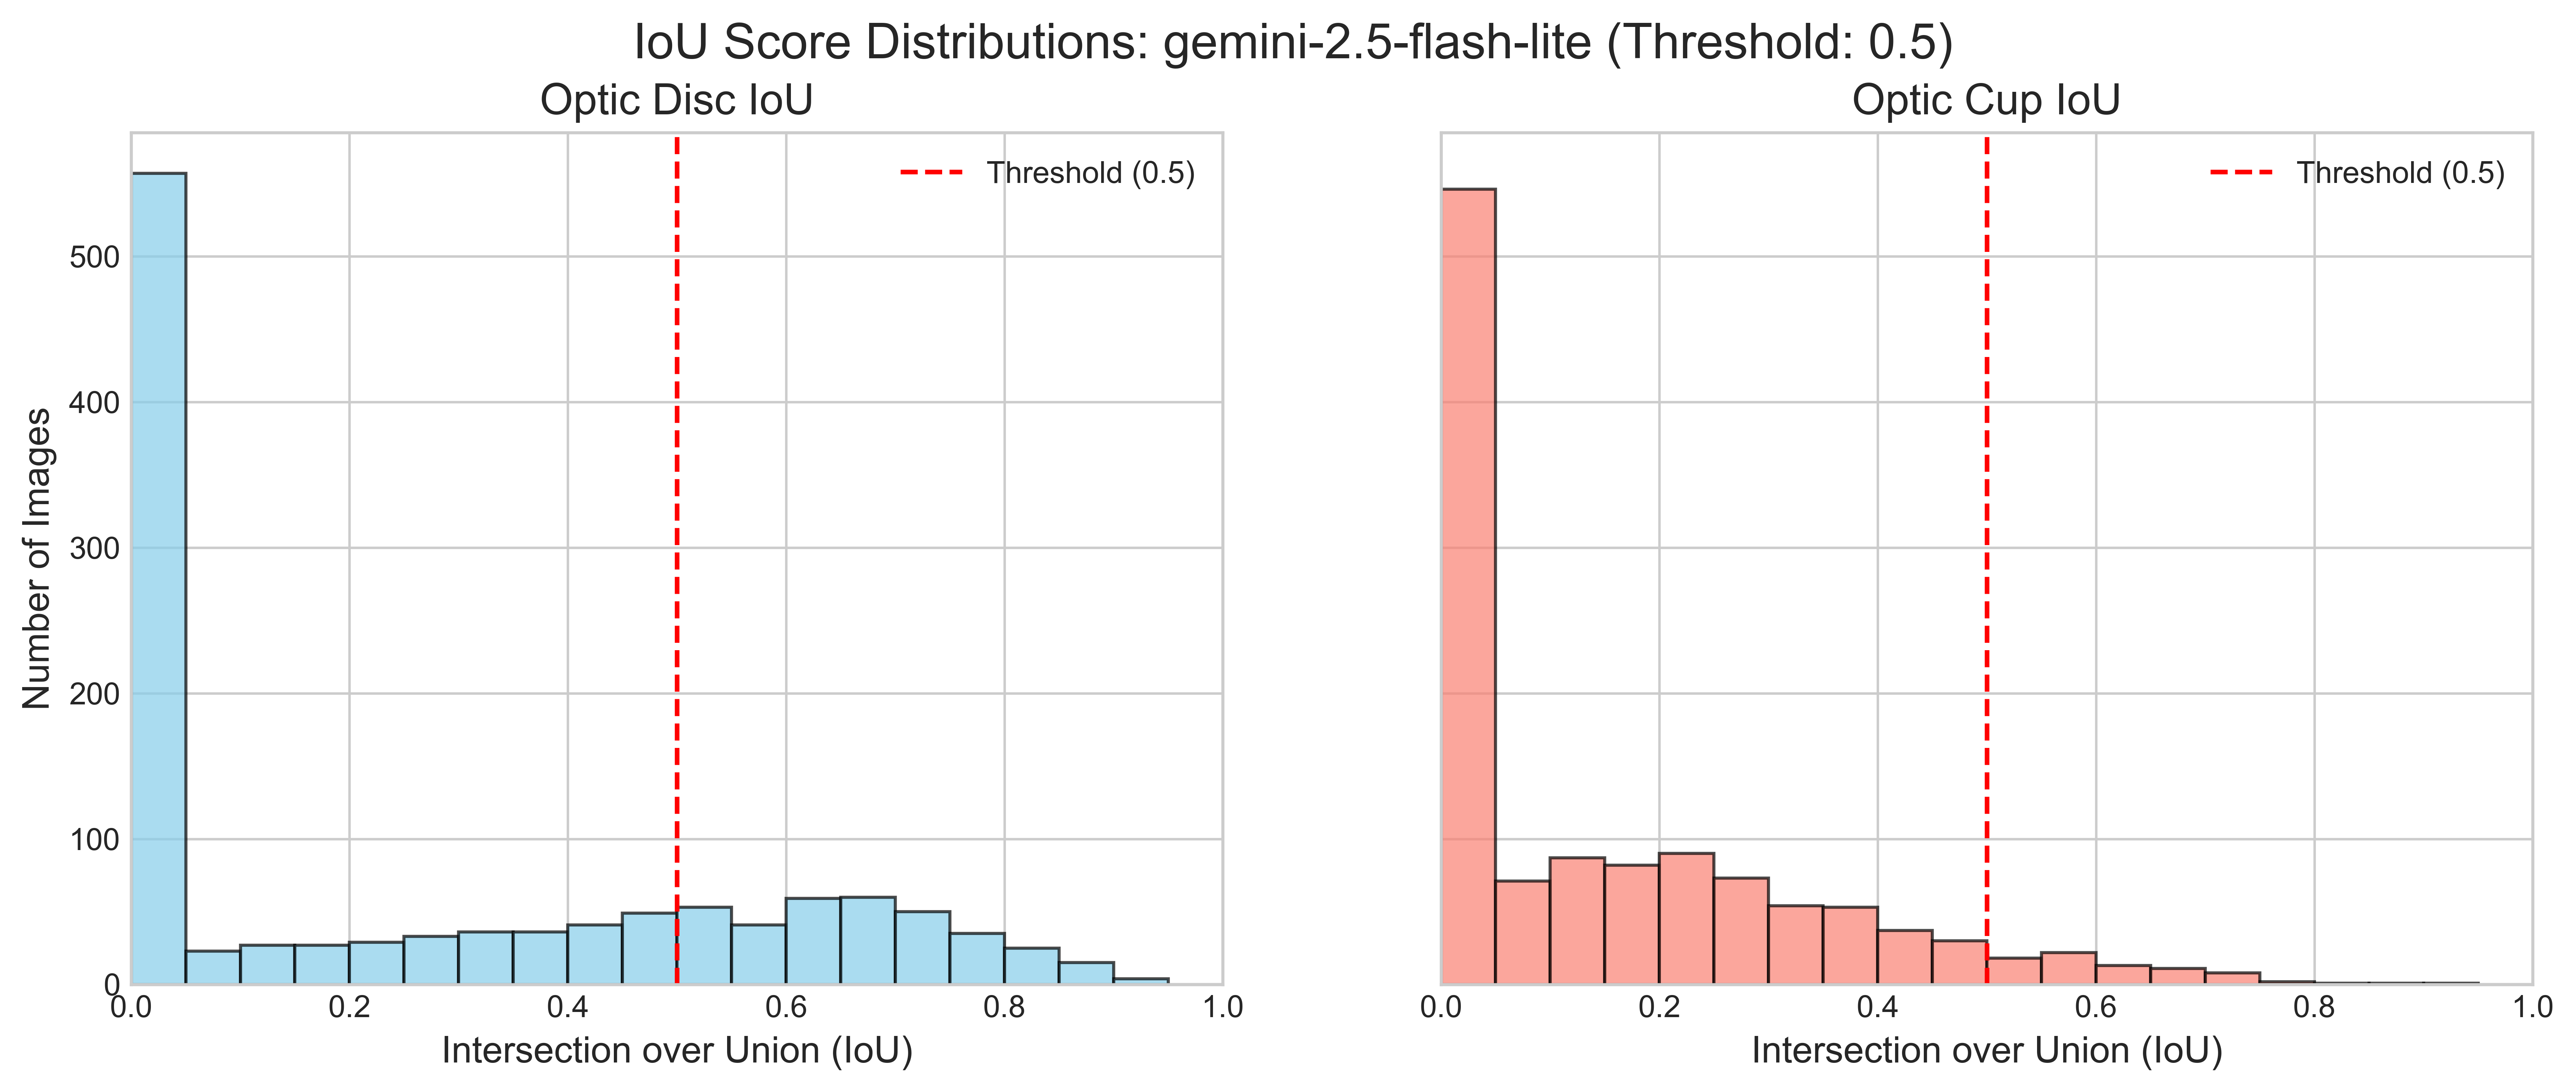

"\n✅ Re-analysis complete. The report above summarizes the model's performance using the new threshold.\n"

In [ ]:
# %% [markdown]
"""
# 06 LITS Results Re-Analysis Tool (Multithreaded)

*Last sync 02 Aug 2025*

This notebook re-calculates and re-plots evaluation metrics from a completed run's
cached predictions for the LITS liver or liver mass segmentation task. It uses
multithreading to accelerate the processing of cached files.

**Instructions:**
1.  Ensure you have run the `04_Model_Evaluation_LITS` notebook with
    `SAVE_PREDICTIONS = True` for the desired target.
2.  Set the `MODEL_TO_ANALYZE` and `TARGET_TO_ANALYZE` variables below.
3.  Set the `NEW_LOW_IOU_THRESHOLD` to the desired value for defining a "successful" detection.
4.  Use the `EXCLUDE_LOW_IOU_FROM_STATS` toggle to control the analysis behavior.
"""

# %%
# ---------- Preamble & Setup ----------
import sys, logging, os, subprocess, importlib.util, json, io, base64, dataclasses
from datetime import datetime
from pathlib import Path
from typing import Tuple, List, Optional, Dict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Re-analysis notebook start.")

# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow", "pandas"):
    _ensure(extra)

# %%
# ---------- Dataset Path & Helper Functions ----------
# MODIFIED: Point to the LITS dataset directory.
dataset_dir = Path("data/LITS").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("LITS dataset found at %s", dataset_dir)


def load_prediction_from_cache(prediction_path: Path, target_shape: Tuple[int, int], target_label: str) -> np.ndarray:
    """
    Loads a cached prediction JSON, combines all masks matching the target_label into one,
    and returns a single boolean mask.
    """
    default_mask = np.zeros(target_shape, dtype=bool)
    if not prediction_path.exists():
        logging.error(f"Prediction cache file not found: {prediction_path}")
        return default_mask

    with open(prediction_path, 'r') as f:
        try:
            items = json.load(f)
        except json.JSONDecodeError:
            logging.error(f"Could not decode JSON from cached file: {prediction_path}")
            return default_mask

    if not items:
        return default_mask

    combined_mask_np = np.zeros(target_shape, dtype=bool)
    for item in items:
        try:
            # MODIFIED: Only combine masks that match the target label
            if item.get("label", "").lower() == target_label.lower():
                png_b64_str = item["mask_b64"]
                png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
                mask_img = Image.open(io.BytesIO(png_bytes))
                mask_np = np.array(mask_img)
                combined_mask_np = np.logical_or(combined_mask_np, mask_np > 127)
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in cached prediction: {item}. Error: {e}")
            continue
    return combined_mask_np

def parse_ground_truth_mask(mask_path: Path) -> Tuple[Optional[np.ndarray], Tuple[int, int]]:
    """
    Parses a LITS ground truth PNG file into a binarized boolean NumPy array.
    Returns the boolean mask and its shape.
    """
    try:
        mask_img = Image.open(mask_path).convert("L")
        mask_data = np.array(mask_img)
        # MODIFIED: Use > 0 to handle faint masks correctly.
        return mask_data > 0, mask_data.shape
    except (FileNotFoundError, UnidentifiedImageError) as e:
        logging.error("Could not read ground truth mask file %s: %s", mask_path, e)
        return None, (0, 0)

# %%
# ---------- Metric Calculation Functions ----------

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 1.0
    return np.sum(intersection) / np.sum(union)

def calculate_dice(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates the Dice Coefficient for boolean masks."""
    intersection = np.sum(np.logical_and(y_true, y_pred))
    denominator = np.sum(y_true) + np.sum(y_pred)
    if denominator == 0: return 1.0
    return (2. * intersection) / (denominator + 1e-7)

def calculate_bootstrap_ci(data: List[float], n_resamples: int = 1000) -> Tuple[float, float]:
    """Calculates the 95% confidence interval for a list of numbers using bootstrapping."""
    if not data or len(data) < 2: return 0.0, 0.0
    bootstrapped_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_resamples)]
    return np.percentile(bootstrapped_means, 2.5), np.percentile(bootstrapped_means, 97.5)

# %% [markdown]
"""
### Re-Analysis Execution

This section loads the cached predictions, recalculates all metrics in parallel, and then generates a new report and plot based on the parameters you set below.
"""

# %%
# ---------- Main Re-Analysis Loop ----------

# <<< --- PARAMETERS TO CONTROL THE RE-ANALYSIS --- >>>
MODEL_TO_ANALYZE = "gemini-2.5-flash"
TARGET_TO_ANALYZE = "liver" # Options: "liver", "liver mass"
NEW_LOW_IOU_THRESHOLD = 0.75
EXCLUDE_LOW_IOU_FROM_STATS = True
MAX_WORKERS = os.cpu_count() or 4

# --- Setup paths and find prediction files ---
model_name_safe = MODEL_TO_ANALYZE.replace("/", "_")
target_safe = TARGET_TO_ANALYZE.replace(" ", "_")
predictions_dir = dataset_dir / f"predictions_{target_safe}_{model_name_safe}"
if not predictions_dir.is_dir():
    raise FileNotFoundError(f"Predictions directory not found for model '{MODEL_TO_ANALYZE}' and target '{TARGET_TO_ANALYZE}'. Please run the evaluation script first.")

prediction_files = list(predictions_dir.glob("*.json"))
if not prediction_files:
    raise FileNotFoundError(f"No prediction files found in {predictions_dir}.")

logging.info(f"Found {len(prediction_files)} cached predictions for model '{MODEL_TO_ANALYZE}' and target '{TARGET_TO_ANALYZE}'.")
logging.info(f"Starting re-analysis with up to {MAX_WORKERS} threads.")

# --- Load Master CSV for lookups ---
lits_csv_path = dataset_dir / "lits_df.csv"
if not lits_csv_path.exists():
    raise FileNotFoundError(f"Master CSV not found: {lits_csv_path}")
lits_df = pd.read_csv(lits_csv_path)
lits_df['filename'] = lits_df['filepath'].apply(lambda p: Path(p).name)
lits_df = lits_df.set_index('filename')

def correct_path(p: str, base_dir: Path) -> Path:
    parts = Path(p).parts
    if len(parts) >= 2:
        return base_dir / parts[-2] / parts[-1]
    return Path(p)

# --- Worker function for parallel processing ---
def process_single_prediction(pred_path: Path) -> Optional[Dict]:
    """Processes a single prediction file to calculate metrics for the LITS dataset."""
    image_filename = f"{pred_path.stem}.png"
    
    if image_filename not in lits_df.index:
        return None
        
    case_row = lits_df.loc[image_filename]
    
    if TARGET_TO_ANALYZE == "liver":
        mask_path = correct_path(case_row['liver_maskpath'], dataset_dir)
    else:
        mask_path = correct_path(case_row['tumor_maskpath'], dataset_dir)
        
    if not mask_path.exists():
        return None

    gt_mask, gt_shape = parse_ground_truth_mask(mask_path)
    if gt_mask is None:
        return None

    predicted_mask = load_prediction_from_cache(pred_path, target_shape=gt_shape, target_label=TARGET_TO_ANALYZE)

    iou = calculate_iou(gt_mask, predicted_mask)
    dice = calculate_dice(gt_mask, predicted_mask)

    return {"image_path": image_filename, "iou": iou, "dice": dice}

# --- Recalculate metrics in parallel ---
recalculated_results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    results_iterator = executor.map(process_single_prediction, prediction_files)
    for result in tqdm(results_iterator, total=len(prediction_files), desc=f"Re-analyzing {target_safe}"):
        if result is not None:
            recalculated_results.append(result)


# %% [markdown]
"""
### New Results Summary

The following report is generated from the recalculated metrics using your specified IoU threshold.
"""

# %%
# ---------- Aggregate, Display, and Save New Results ----------

if recalculated_results:
    df = pd.DataFrame(recalculated_results)

    if EXCLUDE_LOW_IOU_FROM_STATS:
        logging.info(f"Excluding cases with IoU < {NEW_LOW_IOU_THRESHOLD} from stats calculations.")
        runs_for_stats = df[df['iou'] >= NEW_LOW_IOU_THRESHOLD]
    else:
        logging.info("Including all cases (even IoU=0) in stats calculations.")
        runs_for_stats = df

    mean_iou = runs_for_stats['iou'].mean() if not runs_for_stats.empty else 0
    mean_dice = runs_for_stats['dice'].mean() if not runs_for_stats.empty else 0

    total_runs = len(df)
    num_false_negatives = len(df[df['iou'] == 0])
    num_low_iou_failures = len(df[(df['iou'] > 0) & (df['iou'] < NEW_LOW_IOU_THRESHOLD)])

    iou_ci = calculate_bootstrap_ci(runs_for_stats['iou'].tolist())
    dice_ci = calculate_bootstrap_ci(runs_for_stats['dice'].tolist())

    print("---" * 15)
    print(f"         LITS Segmentation Re-Analysis Report: {MODEL_TO_ANALYZE}")
    print(f"         Target: {TARGET_TO_ANALYZE.title()}")
    print("---" * 15)
    print(f"Total Cached Predictions Analyzed: {total_runs}")
    print(f"New IoU Threshold for Success:     {NEW_LOW_IOU_THRESHOLD}")
    print(f"Excluding Low IoU from Stats:      {EXCLUDE_LOW_IOU_FROM_STATS}")

    print("\n--- Performance Metrics ---")
    print(f"Mean IoU:                      {mean_iou:.4f} (95% CI: {iou_ci[0]:.4f} - {iou_ci[1]:.4f}) on {len(runs_for_stats)} images")
    print(f"Mean Dice Coefficient:         {mean_dice:.4f} (95% CI: {dice_ci[0]:.4f} - {dice_ci[1]:.4f})")

    print("\n--- Failure Analysis (New Threshold) ---")
    print(f"False Negatives (IoU=0): {num_false_negatives} ({num_false_negatives/total_runs:.1%})")
    print(f"Low IoU Failures:        {num_low_iou_failures} ({num_low_iou_failures/total_runs:.1%})")
    print("---" * 15)
    
    summary_data = {
        "reanalysis_timestamp": datetime.now().isoformat(),
        "total_cached_predictions_analyzed": total_runs,
        "settings": {
            "model_analyzed": MODEL_TO_ANALYZE,
            "target_analyzed": TARGET_TO_ANALYZE,
            "new_low_iou_threshold": NEW_LOW_IOU_THRESHOLD,
            "excluded_low_iou_from_stats": EXCLUDE_LOW_IOU_FROM_STATS,
        },
        "performance_metrics": {
            "mean_iou": mean_iou, "mean_dice": mean_dice,
            "mean_iou_95_ci": iou_ci, "mean_dice_95_ci": dice_ci,
            "num_images_in_stat_calc": len(runs_for_stats),
        },
        "failure_counts": { "false_negatives": num_false_negatives, "low_iou_failures": num_low_iou_failures }
    }
    
    summary_path = dataset_dir / f"reanalysis_summary_{target_safe}_{model_name_safe}_thresh_{NEW_LOW_IOU_THRESHOLD}.json"
    with open(summary_path, 'w') as f:
        json.dump(summary_data, f, indent=4)
    logging.info(f"Saved re-analysis summary to {summary_path}")

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6), dpi=600)
    fig.suptitle(f'IoU Score Distribution (LITS): {MODEL_TO_ANALYZE}', fontsize=16)

    ax.hist(df['iou'], bins=20, range=(0,1), edgecolor='black', alpha=0.75, color='c')
    ax.set_title(f'{TARGET_TO_ANALYZE.title()} Segmentation IoU (n={total_runs})', fontsize=14)
    ax.set_xlabel('Intersection over Union (IoU)', fontsize=12)
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.axvline(NEW_LOW_IOU_THRESHOLD, color='r', linestyle='--', label=f'Threshold ({NEW_LOW_IOU_THRESHOLD})')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

    plot_path = dataset_dir / f"reanalysis_iou_dist_{target_safe}_{model_name_safe}_thresh_{NEW_LOW_IOU_THRESHOLD}.png"
    plt.savefig(plot_path, bbox_inches='tight')
    logging.info(f"Saved re-analysis IoU plot to {plot_path}")
    plt.show()
else:
    print("No recalculated results were generated. Check if prediction files exist.")

# %% [markdown]
"""
✅ Re-analysis complete. The report above summarizes the model's performance using the new threshold.
"""
